# WP1.9 - Load Allocation

This notebook implements and validates a load-allocation algorithm for multiphase radial networks using pandapower multiconductor.
The considered tests here test the connected capacity option of load allocation for different test cases. The notebook performs the following:
1. Builds Test Networks - 5 bus and 20 bus consisting of ext_grid, asymmetric loads, sgens, transformer
2. Adds different measurement configurations
3. Runs the Load Allocation algorithm
4. Validates Measurements against final powerflow 

In [1]:
import multiconductor as mc
from load_allocation import build_measurement_graph, run_load_allocation, get_simulated_measurement_value, get_measurement_bus, get_downstream_load_indices, filter_loads_under_other_measurement
import numpy as np
import pandas as pd
from multiconductor.pycci.std_types import create_std_type
import matplotlib.pyplot as plt
import networkx as nx
import pandapower.plotting as plot

In [2]:
def _create_matrix_type_line(mc_net, conductors, type_name, rvalue=0.02, xvalue=0.07):
    rmatrix = np.zeros(shape=(conductors, conductors))
    xmatrix = np.zeros(shape=(conductors, conductors))
    for i in range(0, conductors):
        rmatrix[i, i] = rvalue
        xmatrix[i, i] = xvalue

    mdata = {"r_1_ohm_per_km": rmatrix[:, 0],
             "x_1_ohm_per_km": xmatrix[:, 0],
             "g_1_us_per_km": np.zeros(conductors),
             "b_1_us_per_km": np.zeros(conductors),
             "max_i_ka": np.ones(conductors)
             }

    if conductors >= 2:
        mdata.update({"r_2_ohm_per_km": rmatrix[:, 1],
                      "x_2_ohm_per_km": xmatrix[:, 1],
                      "g_2_us_per_km": np.zeros(conductors),
                      "b_2_us_per_km": np.zeros(conductors)})
    if conductors >= 3:
        mdata.update({"r_3_ohm_per_km": rmatrix[:, 2],
                      "x_3_ohm_per_km": xmatrix[:, 2],
                      "g_3_us_per_km": np.zeros(conductors),
                      "b_3_us_per_km": np.zeros(conductors)})
    if conductors == 4:
        mdata.update({"r_4_ohm_per_km": rmatrix[:, 3],
                      "x_4_ohm_per_km": xmatrix[:, 3],
                      "g_4_us_per_km": np.zeros(conductors),
                      "b_4_us_per_km": np.zeros(conductors)})
    if conductors > 4:
        print("_create_matrix_type_line: Error: doesn't support more than 4 conductors")

    mc.pycci.std_types.create_std_types(mc_net, {type_name: mdata}, element="matrix")

def _create_trafo_types(mc_net):    
    create_std_type(mc_net, {"sn_mva": 50,
                "vn_hv_kv": 115,
                "vn_lv_kv": 16,
                "vk_percent": .001,
                "vkr_percent": 0,
                "pfe_kw": 0,
                "i0_percent": .001,
                "shift_degree": 0,
                "vector_group": "Yyn0",
                "tap_side": "lv",
                "tap_neutral": 0,
                "tap_min": -16,
                "tap_max": 16,
                "tap_step_degree": 0,
                "tap_step_percent": 0.625,
                "tap_changer_type": "Ratio"}, name="50MVA_Yy_LDC", element="trafo")
    create_std_type(mc_net, {"sn_mva": 10,
                "vn_hv_kv": 115,
                "vn_lv_kv": 16,
                "vk_percent": 6,
                "vkr_percent": 0,
                "pfe_kw": 0,
                "i0_percent": 4,
                "shift_degree": 0,
                "vector_group": "Yyn0",
                "tap_side": "lv",
                "tap_neutral": 0,
                "tap_min": -16,
                "tap_max": 16,
                "tap_step_degree": 0,
                "tap_step_percent": 0.625,
                "tap_changer_type": "Ratio"}, name="10MVA_Yy_LDC", element="trafo")
    create_std_type(mc_net, {"sn_mva": 1,
                "vn_hv_kv": 16,
                "vn_lv_kv": 0.4,
                "vk_percent": 8,
                "vkr_percent": 0,
                "pfe_kw": 0,
                "i0_percent": 5,
                "shift_degree": 0,
                "vector_group": "Yyn0",
                "tap_side": "lv",
                "tap_neutral": 0,
                "tap_min": -16,
                "tap_max": 16,
                "tap_step_degree": 0,
                "tap_step_percent": 0.625,
                "tap_changer_type": "Ratio"}, name="1MVA_HVLV_Yy_LDC", element="trafo")

def add_line_p_measurement_value(net, line_idx, value_mw, side="from",
                                 meas_index=None, std_dev=0.01, name=None):

    mc.create_measurement(
        net,
        measurement_type="p",
        element_type="line",
        element=line_idx,
        value=float(value_mw),
        std_dev=std_dev,
        side=side,
        name=name,
        index=meas_index
    )


def add_trafo_p_measurement_value(net, trafo_idx, side="hv",
                                  value_mw=0.0, meas_index=None,
                                  std_dev=0.01, name=None):
    mc.create_measurement(
        net,
        measurement_type="p",
        element_type="trafo1ph",
        element=trafo_idx,
        value=float(value_mw),
        std_dev=std_dev,
        side=side,
        index=meas_index,
        name=name
    )

def add_ext_grid_p_measurement_value(net, element, value_mw, meas_index, name):
    """
    Create a P measurement at an ext_grid element.
    'element' = ext_grid index (integer)
    """
    if "measurement" not in net:
        raise RuntimeError("net.measurement table missing")

    net.measurement.loc[meas_index, ["element_type", "element",
                                     "measurement_type", "side",
                                     "value", "name"]] = [
        "ext_grid", element, "p", "from", float(value_mw), name
    ]


def get_measurement_nodes(net, mg):
    """
    Return a list of (bus, phase) nodes where measurements are located.
    """
    meas_nodes = []

    for idx in net.measurement.index:
        meas = net.measurement.loc[idx]
        if isinstance(meas, pd.DataFrame):
            meas = meas.iloc[0]

        bus = get_measurement_bus(net, meas)

        # all phase-nodes at that bus
        bus_phase_nodes = [n for n in mg.nodes if n[0] == bus]
        meas_nodes.extend(bus_phase_nodes)

    return meas_nodes

In [3]:
def create_net():
    net = mc.create_empty_network()
    bus0 = mc.create_bus(net, num_phases=4, vn_kv=115, name="bus0") 
    bus1 = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus1")
    bus2 = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus2")
    bus3 = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus3")

    grounding_r_ohm=1E-7
    net.bus.at[(0, 0), 'grounded'] = True
    net.bus.at[(0, 0), 'grounding_r_ohm'] = grounding_r_ohm
    net.bus.at[(1, 0), 'grounded'] = True
    net.bus.at[(1, 0), 'grounding_r_ohm'] = grounding_r_ohm
    net.bus.at[(2, 0), 'grounded'] = False
    net.bus.at[(2, 0), 'grounding_r_ohm'] = grounding_r_ohm
    net.bus.at[(3, 0), 'grounded'] = False
    net.bus.at[(3, 0), 'grounding_r_ohm'] = grounding_r_ohm
    mc.create_ext_grid_sequence(
        net, bus=bus0, from_phase=(1, 2, 3), to_phase=0, vm_pu=1, va_degree=0,
        sn_mva=50, rx=0, x0x=1, r0x0=0, name="extgrid")

    _create_matrix_type_line(net, conductors=3, type_name="mat_line_3cond")
    _create_matrix_type_line(net, conductors=4, type_name="mat_line_4cond")
    _create_trafo_types(net)
        
    mc.create_transformer_3ph(net, hv_bus=bus0, lv_bus=bus1, std_type="10MVA_Yy_LDC")
    mc.create_line(net, model_type="matrix", std_type="mat_line_4cond", from_bus=bus1, from_phase=(0, 1, 2, 3),
                    to_bus=bus2, to_phase=(0, 1, 2, 3), length_km=12, name="Line1_2")
    mc.create_line(net, model_type="matrix", std_type="mat_line_4cond", from_bus=bus2, from_phase=(0, 1, 2, 3),
                    to_bus=bus3, to_phase=(0, 1, 2, 3), length_km=12, name="Line2_3")    
    mc.create_asymmetric_load(net, bus3, from_phase=(1,2,3), to_phase=0, p_mw=6, q_mvar=1, name="Load1")

    return net

In [4]:
def create_five_bus_radial_net():
    
    net = mc.create_empty_network()

    bus0 = mc.create_bus(net, num_phases=4, vn_kv=115, name="bus0")
    bus1 = mc.create_bus(net, num_phases=4, vn_kv=16,  name="bus1")
    bus2 = mc.create_bus(net, num_phases=4, vn_kv=16,  name="bus2")
    bus3 = mc.create_bus(net, num_phases=4, vn_kv=16,  name="bus3")
    bus4 = mc.create_bus(net, num_phases=4, vn_kv=16,  name="bus4")

    mc.create_ext_grid_sequence(
        net, bus=bus0, from_phase=(1, 2, 3), to_phase=0,
        vm_pu=1.0, va_degree=0,
        sn_mva=50, rx=0, x0x=1, r0x0=0,
        name="extgrid",
    )

    _create_matrix_type_line(net, conductors=4, type_name="mat_line_4cond")
    _create_trafo_types(net)

    mc.create_transformer_3ph(net, hv_bus=bus0, lv_bus=bus1, std_type="10MVA_Yy_LDC")

    mc.create_line(net, model_type="matrix", std_type="mat_line_4cond",
                   from_bus=bus1, from_phase=(0, 1, 2, 3),
                   to_bus=bus2,   to_phase=(0, 1, 2, 3),
                   length_km=1.0, name="L1_2")

    mc.create_line(net, model_type="matrix", std_type="mat_line_4cond",
                   from_bus=bus2, from_phase=(0, 1, 2, 3),
                   to_bus=bus3,   to_phase=(0, 1, 2, 3),
                   length_km=1.0, name="L2_3")

    mc.create_line(net, model_type="matrix", std_type="mat_line_4cond",
                   from_bus=bus2, from_phase=(0, 1, 2, 3),
                   to_bus=bus4,   to_phase=(0, 1, 2, 3),
                   length_km=1.0, name="L2_4")

    mc.create_asymmetric_load(net, bus2, from_phase=(1, 2, 3), to_phase=0,
                              p_mw=6.0, q_mvar=1.0, name="Load_bus2")

    mc.create_asymmetric_load(net, bus3, from_phase=(1, 2, 3), to_phase=0,
                              p_mw=4.0, q_mvar=0.8, name="Load_bus3")

    mc.create_asymmetric_sgen(net, bus=bus4, from_phase=(1, 2, 3), to_phase=0,
                              p_mw=(2.0, 2.0, 2.0), q_mvar=(0.0, 0.0, 0.0), name="sgen_bus4")

    return net

In [5]:
def create_20bus_radial_net():
    
    """
    20-bus radial system:

      bus0: HV bus with ext_grid
      bus1: LV bus 
      Three LV feeders:

        Feeder 1: 1-2-3-4-5-6-7
        Feeder 2: 1-8-9-10-11-12-13
        Feeder 3: 1-14-15-16-17-18-19

      Asymmetric loads on all three feeders,
      sgen on feeder 1 and feeder 2
      
    """

    net = mc.create_empty_network()

    bus0 = mc.create_bus(net, num_phases=4, vn_kv=115, name="bus0_HV")
    bus1 = mc.create_bus(net, num_phases=4, vn_kv=16,  name="bus1_LV")

    bus2  = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus2_F1")
    bus3  = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus3_F1")
    bus4  = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus4_F1")
    bus5  = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus5_F1")
    bus6  = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus6_F1")
    bus7  = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus7_F1_end")

    bus8  = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus8_F2")
    bus9  = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus9_F2")
    bus10 = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus10_F2")
    bus11 = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus11_F2")
    bus12 = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus12_F2")
    bus13 = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus13_F2_end")

    bus14 = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus14_F3")
    bus15 = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus15_F3")
    bus16 = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus16_F3")
    bus17 = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus17_F3")
    bus18 = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus18_F3")
    bus19 = mc.create_bus(net, num_phases=4, vn_kv=16, name="bus19_F3_end")

    mc.create_ext_grid_sequence(
        net, bus=bus0, from_phase=(1, 2, 3), to_phase=0,
        vm_pu=1.0, va_degree=0.0,
        sn_mva=50.0, rx=0.0, x0x=1.0, r0x0=0.0,
        name="ext_grid"
    )

    _create_matrix_type_line(net, conductors=4, type_name="mat_line_4cond")
    _create_trafo_types(net)

    mc.create_transformer_3ph(net, hv_bus=bus0, lv_bus=bus1, std_type="10MVA_Yy_LDC")

    # line creation
    def create_feeder_lines(buses, name):
        for i in range(len(buses) - 1):
            mc.create_line(
                net, model_type="matrix", std_type="mat_line_4cond",
                from_bus=buses[i], from_phase=(0, 1, 2, 3),
                to_bus=buses[i+1], to_phase=(0, 1, 2, 3),
                length_km=1.0,
                name=f"{name}_{i}"
            )

    # feeder 1: 1-2-3-4-5-6-7
    create_feeder_lines([bus1, bus2, bus3, bus4, bus5, bus6, bus7], "F1")

    # feeder 2: 1-8-9-10-11-12-13
    create_feeder_lines([bus1, bus8, bus9, bus10, bus11, bus12, bus13], "F2")

    # feeder 3: 1-14-15-16-17-18-19
    create_feeder_lines([bus1, bus14, bus15, bus16, bus17, bus18, bus19], "F3")

    # Feeder 1 loads
    mc.create_asymmetric_load(net, bus3,  from_phase=(1, 2, 3), to_phase=0,
                              p_mw=3.0, q_mvar=0.6, name="Load_F1_bus3")
    mc.create_asymmetric_load(net, bus5,  from_phase=(1, 2, 3), to_phase=0,
                              p_mw=2.0, q_mvar=0.4, name="Load_F1_bus5")
    mc.create_asymmetric_load(net, bus7,  from_phase=(1, 2, 3), to_phase=0,
                              p_mw=1.0, q_mvar=0.2, name="Load_F1_bus7")

    # Feeder 2 loads
    mc.create_asymmetric_load(net, bus9,  from_phase=(1, 2, 3), to_phase=0,
                              p_mw=2.0, q_mvar=0.4, name="Load_F2_bus9")
    mc.create_asymmetric_load(net, bus11, from_phase=(1, 2, 3), to_phase=0,
                              p_mw=3.0, q_mvar=0.6, name="Load_F2_bus11")
    mc.create_asymmetric_load(net, bus13, from_phase=(1, 2, 3), to_phase=0,
                              p_mw=1.0, q_mvar=0.2, name="Load_F2_bus13")

    # Feeder 3 loads
    mc.create_asymmetric_load(net, bus15, from_phase=(1, 2, 3), to_phase=0,
                              p_mw=2.0, q_mvar=0.4, name="Load_F3_bus15")
    mc.create_asymmetric_load(net, bus17, from_phase=(1, 2, 3), to_phase=0,
                              p_mw=2.0, q_mvar=0.4, name="Load_F3_bus17")
    mc.create_asymmetric_load(net, bus19, from_phase=(1, 2, 3), to_phase=0,
                              p_mw=1.0, q_mvar=0.2, name="Load_F3_bus19")

    # sgen on two feeders
    mc.create_asymmetric_sgen(net, bus=bus7, from_phase=(1, 2, 3), to_phase=0,
                              p_mw=(0.7, 0.7, 0.7), q_mvar=(0.0, 0.0, 0.0),
                              name="PV_F1_bus7")

    mc.create_asymmetric_sgen(net, bus=bus11, from_phase=(1, 2, 3), to_phase=0,
                              p_mw=(1.0, 1.0, 1.0), q_mvar=(0.0, 0.0, 0.0),
                              name="PV_F2_bus11")

    return net

In [6]:
def phase_grid_pos(mg):
    pos = {}
    for (bus, ph) in mg.nodes:
        pos[(bus, ph)] = (bus, -ph)
    return pos

def split_edges_by_type(mg):
    line_edges, switch_edges, trafo_edges = [], [], []
    for u, v, k in mg.edges(keys=True):
        etype = k[0]
        if etype == "line":
            line_edges.append((u, v))
        elif etype == "switch":
            switch_edges.append((u, v))
        elif etype == "trafo1ph":
            trafo_edges.append((u, v))
    return line_edges, switch_edges, trafo_edges

index  circuit
0      1          0.742502
Name: i_from_ka, dtype: float64

In [7]:
def plot_bus_level_from_mg(mg, title="Bus-level diagram"):
    G = nx.DiGraph()

    for u, v, key in mg.edges(keys=True):
        bu, bv = int(u[0]), int(v[0])
        if bu == bv:
            continue
        kind = key[0] 
        if not G.has_edge(bu, bv):
            G.add_edge(bu, bv, kind=kind)

    pos = nx.spring_layout(G, seed=1)

    plt.figure(figsize=(8, 5))
    nx.draw_networkx_nodes(G, pos, node_size=90)
    nx.draw_networkx_labels(G, pos)

    edge_colors = []
    for (a, b) in G.edges():
        kind = G[a][b].get("kind", "line")
        edge_colors.append({"line": "black", "switch": "orange", "trafo1ph": "blue"}.get(kind, "gray"))

    nx.draw_networkx_edges(G, pos, arrows=True, edge_color=edge_colors, width=2)
    plt.title(title)
    plt.axis("off")
    plt.show()

## Test 1: Single Measurement

1. Creates a simple 4-bus radial network and adds a single 8 MW line-flow measurement.

2. Builds and visualizes the measurement graph, then identifies the downstream loads affected by that measurement.

3. Runs the load-allocation algorithm with iterative power-flow correction to adjust those loads.

4. Performs a final PF and verifies that the simulated line flow matches the 8 MW target.

In [8]:
def test_single_measurement():
    print("\nTest 1: single measurement")
    net = create_net()
    add_line_p_measurement_value(net, line_idx=0, side="from", value_mw=8.0, meas_index=0)
    mc.run_pf(net)
    mg = build_measurement_graph(net)
    measurement_nodes = get_measurement_nodes(net, mg)
    pos = phase_grid_pos(mg)
    line_edges, switch_edges, trafo_edges = split_edges_by_type(mg)
    plt.figure(figsize=(10, 6))
    nx.draw_networkx_nodes(mg, pos, node_size=500, nodelist=mg.nodes, node_color="tab:blue")
    nx.draw_networkx_nodes(mg, pos, node_size=500,  nodelist=measurement_nodes, node_color="tab:red")
    nx.draw_networkx_edges(mg, pos, edgelist=line_edges, edge_color="black", width=1.5, arrows=True)
    nx.draw_networkx_edges(mg, pos, edgelist=switch_edges, edge_color="orange", width=1.5, arrows=True)
    nx.draw_networkx_edges(mg, pos, edgelist=trafo_edges, edge_color="blue", width=2.5, arrows=True)
    nx.draw_networkx_labels(mg, pos, font_size=8, font_color="white")
    plt.title("Phase-level measurement graph (bus,phase)")
    plt.axis("off")
    plt.show()
    for midx in [0]:
        loads = get_downstream_load_indices(net, mg, midx)
        loads = filter_loads_under_other_measurement(net, mg, loads, midx)
        print(f"measurement {midx} downstream loads:", loads)
    run_load_allocation(
        net,
        mg,
        adjust_after_load_flow=True,
        tolerance=0.0001,
        cap_to_load_rating=False,
        measurement_indices=[0],
        verbose=True)

    print("\n asymmetric load results:")
    print(net.asymmetric_load[["p_mw", "q_mvar"]])

    mc.run_pf(net)
    meas = net.measurement.loc[0]
    if isinstance(meas, pd.DataFrame):
        meas = meas.iloc[0]

    target = float(meas["value"])
    sim = get_simulated_measurement_value(net, meas)
    print(f"\nTarget P = {target:.4f} MW, simulated P = {sim:.4f} MW")


Test 1: single measurement


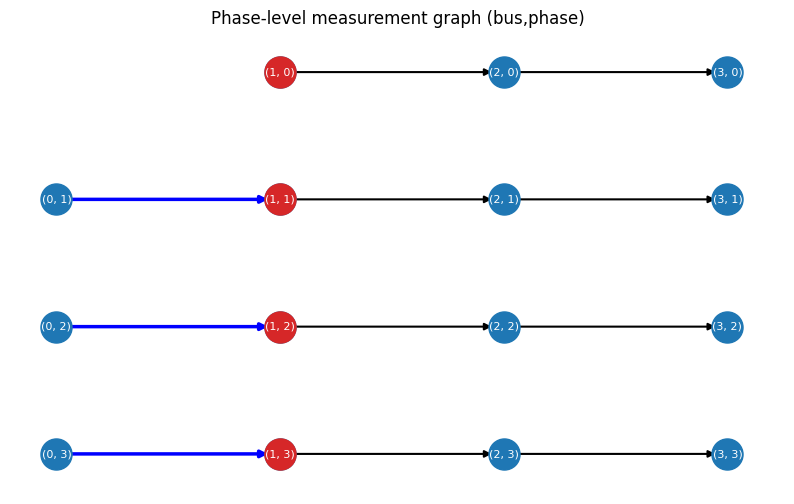

measurement 0 downstream loads: [(0, 1), (0, 2), (0, 0)]

 run_load_allocation for measurement 0
Iter 0: measurement_target=8.0000 MW, sim=8.1557 MW, delta=-1.946%
Iter 1: measurement_target=8.0000 MW, sim=7.9936 MW, delta=0.081%
Iter 2: measurement_target=8.0000 MW, sim=8.0001 MW, delta=-0.002%
Iter 3: measurement_target=8.0000 MW, sim=8.0000 MW, delta=0.000%
Converged within ±0.0001% after 3 iterations

 asymmetric load results:
                   p_mw    q_mvar
index circuit                    
0     0        2.616823  0.981309
      1        2.616823  0.981309
      2        2.616823  0.981309

Target P = 8.0000 MW, simulated P = 8.0000 MW


In [9]:
test_single_measurement()

## Test 2: Two Measurements

1. Build the five-bus radial network and add two active-power measurements on lines L1 and L2 and L2 and L3 with specified target values.

2. Construct and plot the phase-level measurement graph to visualize the topology and the meter locations.

3. Determine the downstream loads for each measurement and filter out any loads that lie under another measurement.

4. Run the load-allocation process in the chosen order, perform a power flow, and compare the target and simulated measurement values.

In [10]:
def test_five_bus_two_meas():
    net = create_five_bus_radial_net()
    mg = build_measurement_graph(net)

    add_line_p_measurement_value(net, line_idx=1, side="from", value_mw=15.0, meas_index=1, name="P_L2_3_from")

    add_line_p_measurement_value(net, line_idx=0, side="from", value_mw=24.0, meas_index=0, name="P_L1_2_from")
    measurement_nodes = get_measurement_nodes(net, mg)
    pos = phase_grid_pos(mg)
    line_edges, switch_edges, trafo_edges = split_edges_by_type(mg)

    plt.figure(figsize=(10, 6))
    nx.draw_networkx_nodes(mg, pos, node_size=500, nodelist=list(mg.nodes), node_color="tab:blue")
    nx.draw_networkx_nodes(mg, pos, node_size=500, nodelist=list(measurement_nodes), node_color="tab:red")
    nx.draw_networkx_edges(mg, pos, edgelist=line_edges, edge_color="black", width=1.5, arrows=True)
    nx.draw_networkx_edges(mg, pos, edgelist=switch_edges, edge_color="orange", width=1.5, arrows=True)
    nx.draw_networkx_edges(mg, pos, edgelist=trafo_edges, edge_color="blue", width=2.5, arrows=True)
    nx.draw_networkx_labels(mg, pos, font_size=8, font_color="white")
    plt.title("Phase-level measurement graph (bus,phase)")
    plt.axis("off")
    plt.show()

    for midx in [1, 0]:
        loads = get_downstream_load_indices(net, mg, midx)
        loads = filter_loads_under_other_measurement(net, mg, loads, midx)
        print(f"measurement {midx} downstream loads:", loads)

    run_load_allocation(net, mg, adjust_after_load_flow=True, tolerance=0.5, measurement_indices=[1, 0], ignore_generators=False, verbose=True)

    mc.run_pf(net)
    for midx in [0, 1]:
        meas = net.measurement.loc[midx]
        if isinstance(meas, pd.DataFrame):
            meas = meas.iloc[0]
        sim = get_simulated_measurement_value(net, meas)
        print(f"  meas {midx}: {meas.name}  target={float(meas.value):6.2f} MW "f"sim={sim:6.2f} MW")

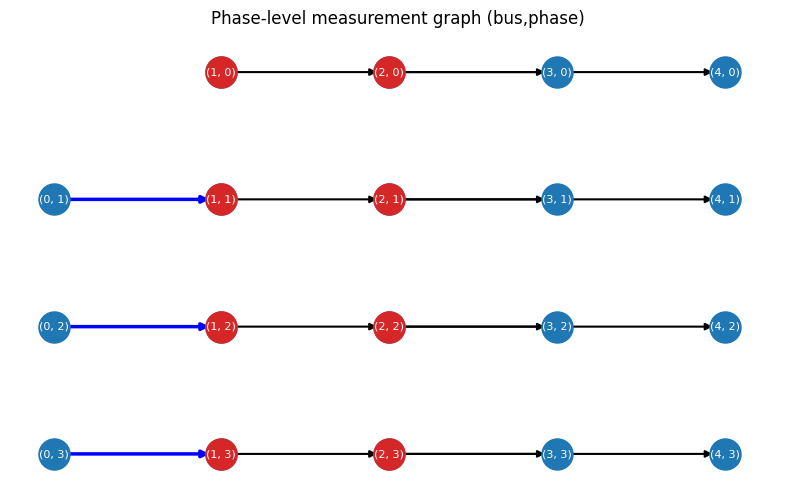

measurement 1 downstream loads: [(1, 0), (1, 1), (1, 2)]
measurement 0 downstream loads: [(0, 1), (0, 2), (0, 0)]

 run_load_allocation for measurement 1
Iter 0: measurement_target=15.0000 MW, sim=15.0203 MW, delta=-0.135%
Converged within ±0.5% after 0 iterations

 run_load_allocation for measurement 0
measurement 0: base=24.0000 MW, downstream=15.0000 MW, residual=9.0000 MW
Iter 0: measurement_target=9.0000 MW, sim=3.0335 MW, delta=66.294%
Iter 1: measurement_target=9.0000 MW, sim=9.0263 MW, delta=-0.292%
Converged within ±0.5% after 1 iterations
  meas 0: 0  target= 24.00 MW sim= 24.05 MW
  meas 1: 1  target= 15.00 MW sim= 15.02 MW


In [11]:
test_five_bus_two_meas()

## Test 2: Measurements on both sides of Trafo and Ignore Generators option

1. The test builds a 5-bus radial network and places active power measurements on the transformer HV side, LV side, and a downstream line.

2. Assigns rated powers to all loads and identifies which loads are downstream of the LV-side transformer measurement.

3. Runs the load allocation algorithm for the line and LV transformer measurements, with and without generators being ignored.

4. Runs a power flow and prints target versus simulated powers for all three measurements to assess consistency.

In [12]:
def test_five_bus_trafo_measurement():
    
    """
      - 5-bus radial net
      - P measurement at trafo HV: 24 MW (index 0)
      - P measurement at trafo LV: 15 MW (index 1)
      - P measurement at line 2 from-side: 10 MW (index 2) with no downstream loads

    Runs load allocation, then a power flow, checks target vs simulated values for each measurement for ignore_generators in (False, True)
    """

    def add_meas_trafo_hv_lv(net, value_hv, value_lv):
        add_trafo_p_measurement_value(
            net, trafo_idx=0, side="hv",
            value_mw=value_hv, meas_index=0, name="P_trafo_hv")
        add_trafo_p_measurement_value(
            net, trafo_idx=0, side="lv",
            value_mw=value_lv, meas_index=1, name="P_trafo_lv")


    for ignore_gen in (False, True):
        print("\n" + "=" * 80)
        print(f"=== 5-bus test: trafo HV+LV+line, ignore_generators={ignore_gen} ===")

        net = create_five_bus_radial_net()
        mg = build_measurement_graph(net)

        add_meas_trafo_hv_lv(net, value_hv=24.0, value_lv=15.0)

        add_line_p_measurement_value(
            net, line_idx=2, side="from",
            value_mw=10.0, meas_index=2, name="P_L2_3_from")

        net.asymmetric_load["sn_mva"] = 10.0

        loads_lv = get_downstream_load_indices(net, mg, 1)
        print("LV trafo measurement downstream loads:", loads_lv)

        run_load_allocation(
            net, mg,
            adjust_after_load_flow=True,
            tolerance=0.05,             
            measurement_indices=[2,1],  
            cap_to_load_rating=True,
            ignore_generators=ignore_gen,
            verbose=True)

        mc.run_pf(net)
        
        def _get_meas_row(idx):
            meas = net.measurement.loc[idx]
            if isinstance(meas, pd.DataFrame):
                meas = meas.iloc[0]
            return meas

        for midx in sorted(net.measurement.index):
            meas = _get_meas_row(midx)
            sim = get_simulated_measurement_value(net, meas)
            target = float(meas.value)

            print(f"  meas {midx}: type={meas.element_type}, side={meas.side} "
                f"target={target:.3f} MW, sim={sim:.3f} MW")

In [13]:
test_five_bus_trafo_measurement()


=== 5-bus test: trafo HV+LV+line, ignore_generators=False ===
LV trafo measurement downstream loads: [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]

 run_load_allocation for measurement 2
measurement 2: no downstream loads to adjust

 run_load_allocation for measurement 1
Iter 0: measurement_target=15.0000 MW, sim=9.0177 MW, delta=39.882%
Iter 1: measurement_target=15.0000 MW, sim=15.0211 MW, delta=-0.140%
Iter 2: measurement_target=15.0000 MW, sim=14.9915 MW, delta=0.057%
Iter 3: measurement_target=15.0000 MW, sim=15.0034 MW, delta=-0.023%
Converged within ±0.05% after 3 iterations
  meas 0: type=trafo1ph, side=hv target=24.000 MW, sim=15.003 MW
  meas 1: type=trafo1ph, side=lv target=15.000 MW, sim=15.003 MW
  meas 2: type=line, side=from target=10.000 MW, sim=-5.997 MW

=== 5-bus test: trafo HV+LV+line, ignore_generators=True ===
LV trafo measurement downstream loads: [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]

 run_load_allocation for measurement 2
measurement 2: no downst

## Test 4: Twenty Bus Network with External Grid and Feeder Head Measurements

1. Builds a 20-bus radial network with three feeders and an external grid.

2. Adds active power measurements at the heads of Feeder 1 and Feeder 2.

3. Runs load allocation for all four combinations of adjust_after_load_flow (on/off) and ignore_generators (on/off).

4. Compares target vs simulated measurements 

In [14]:
def test_twenty_bus_load_allocation_extgrid_and_feeders():
    
    """
    20-bus radial system with:
      - One P measurement at the external grid (index 0)
      - One P measurement on Feeder 1 head (line from bus1 to bus2) (index 1)
      - One P measurement on Feeder 2 head (line from bus1 to bus8) (index 2)
       load allocation cases:
      - adjust_after_load_flow = False / True
      - ignore_generators      = False / True
      
    """

    def add_measurements_20bus(net):

        add_line_p_measurement_value(
            net, line_idx=0, side="from",
            value_mw=5.0,         
            meas_index=1,
            name="P_F1_head"
        )

        add_line_p_measurement_value(
            net, line_idx=6, side="from",
            value_mw=6.0,         
            meas_index=2,
            name="P_F2_head"
        )

    #  sn_mva for all loads for cap_to_load
    def init_load_ratings(net, sn_per_load=5.0):
        if "sn_mva" not in net.asymmetric_load.columns:
            net.asymmetric_load["sn_mva"] = np.nan
        net.asymmetric_load["sn_mva"] = sn_per_load

    def _get_meas_row(net, idx):
        meas = net.measurement.loc[idx]
        if isinstance(meas, pd.DataFrame):
            meas = meas.iloc[0]
        return meas

    for adjust_after_pf in (False, True):
        for ignore_gen in (False, True):
            print("\n" + "=" * 100)
            print(f"=== 20-bus test: adjust_after_load_flow={adjust_after_pf}, "
                f"ignore_generators={ignore_gen} ===")

            net = create_20bus_radial_net()
            mg = build_measurement_graph(net)
            add_measurements_20bus(net)
            init_load_ratings(net, sn_per_load=5.0)

            meas_order = [2, 1]

            run_load_allocation(
                net, mg,
                adjust_after_load_flow=adjust_after_pf,
                tolerance=0.5, 
                measurement_indices=meas_order,
                cap_to_load_rating=True,
                ignore_generators=ignore_gen,
                verbose=True
            )

            # final run_of with generators active 
            mc.run_pf(net)

            print("\nFinal measurement comparison:")
            for midx in sorted(net.measurement.index):
                meas = _get_meas_row(net, midx)
                sim = get_simulated_measurement_value(net, meas)
                target = float(meas.value)
                print(
                    f"  meas {midx}: type={meas.element_type}, side={meas.side} "
                    f"target={target:8.3f} MW, sim={sim:8.3f} MW"
                )

            # total P at line heads
            res_lines = net.res_line[["p_from_mw"]].copy()
            print("\nLine head (p_from_mw) for F1/F2/F3 heads:")
            try:
               p_F1_head = float(res_lines.loc[(0, slice(None)), "p_from_mw"].sum())
               p_F2_head = float(res_lines.loc[(6, slice(None)), "p_from_mw"].sum())
               p_F3_head = float(res_lines.loc[(12, slice(None)), "p_from_mw"].sum())
               print(f"  F1 head :  {p_F1_head:8.3f} MW")
               print(f"  F2 head :  {p_F2_head:8.3f} MW")
               print(f"  F3 head : {p_F3_head:8.3f} MW")
            except Exception as ex:
                print("[WARN] Could not read head line flows:", ex)

            print("=" * 100 + "\n")

In [15]:
test_twenty_bus_load_allocation_extgrid_and_feeders()


=== 20-bus test: adjust_after_load_flow=False, ignore_generators=False ===

 run_load_allocation for measurement 2
adjust_after_load_flow=False, skipping iterative PF adjustment

 run_load_allocation for measurement 1
adjust_after_load_flow=False, skipping iterative PF adjustment

Final measurement comparison:
  meas 1: type=line, side=from target=   5.000 MW, sim=   2.905 MW
  meas 2: type=line, side=from target=   6.000 MW, sim=   3.006 MW

Line head (p_from_mw) for F1/F2/F3 heads:
  F1 head :     2.905 MW
  F2 head :     3.006 MW
  F3 head :   15.061 MW


=== 20-bus test: adjust_after_load_flow=False, ignore_generators=True ===

 run_load_allocation for measurement 2
adjust_after_load_flow=False, skipping iterative PF adjustment

 run_load_allocation for measurement 1
adjust_after_load_flow=False, skipping iterative PF adjustment

Final measurement comparison:
  meas 1: type=line, side=from target=   5.000 MW, sim=   2.905 MW
  meas 2: type=line, side=from target=   6.000 MW, sim= 

In [16]:
## Test 5: Behavior of cap to load rating in a 5-bus network

1. Sets rated power (sn_mva) for all loads

2. Runs allocation with capacity limits enabled

3. Compares with allocation without limits and demonstrates effect of load capping on convergence

SyntaxError: invalid syntax (1330204638.py, line 3)

In [ ]:
def test_cap_to_load_rating_effect():
    
    """
    Demonstrates the effect of cap_to_load_rating on a 5-bus radial network.
      - create five bus radial net (loads on bus2 & bus3).
      - Set each load sn_mva = 5 MVA (rating) and small initial P/Q.
      - Add a single P-measurement at the line (bus1 to  bus2) of 30 MW

    Expected behavior:
      - Without cap_to_load_rating: loads are scaled above 5 MW to match 30 MW.
      - With cap_to_load_rating: each load is clamped at around 5 MW, so the simulated value cannot reach 30 MW.
      
    """

    def run_case(cap_to_load_rating_flag):
        print("\n" + "=" * 80)
        print(f"cap_to_load_rating = {cap_to_load_rating_flag}")

        net = create_five_bus_radial_net()
        mg = build_measurement_graph(net)

        net.asymmetric_load["p_mw"] = 1.0
        net.asymmetric_load["q_mvar"] = 0.2
        net.asymmetric_load["sn_mva"] = 5.0   

        add_line_p_measurement_value(
            net,
            line_idx=0,
            side="from",
            value_mw=30.0,         
            meas_index=0,
            name="P_head_1_2"
        )

        run_load_allocation(
            net,
            mg,
            adjust_after_load_flow=True,
            tolerance=0.5,    
            measurement_indices=[0],
            cap_to_load_rating=cap_to_load_rating_flag,
            ignore_generators=False,
            verbose=True
        )

        mc.run_pf(net)

        print("\nFinal asymmetric loads (per phase):")
        print(net.asymmetric_load[["p_mw", "q_mvar", "sn_mva"]])

        meas = net.measurement.loc[0]
        if isinstance(meas, pd.DataFrame):
            meas = meas.iloc[0]
        target = float(meas.value)
        sim = get_simulated_measurement_value(net, meas)
        print(f"\nHead measurement P target = {target:.3f} MW, simulated = {sim:.3f} MW")

    run_case(cap_to_load_rating_flag=False)
    run_case(cap_to_load_rating_flag=True)

In [ ]:
test_cap_to_load_rating_effect()